# Model-free signal detection — is there ANY on-chain → price signal?

`VALIDATION_PLAN.md` step 3. The ablation showed no *model* extracts an on-chain edge. This asks the prior question, **without any model**: does the data itself contain predictive structure? Three independent tools:

1. **Lead-lag correlation** — feature(t) vs forward return over 3/7/14/30d. Linear only. Significance via **Newey-West HAC** SE (lag = horizon), because overlapping forward returns are autocorrelated and the naive iid p-value massively overstates significance.
2. **Granger causality** — does a feature's past improve the next-day return forecast beyond the return's own past? Hand-rolled F-test (numpy + scipy, no statsmodels). Features first-differenced; target = stationary daily log return.
3. **Mutual information** — *any* dependence (non-linear included) between feature(t) and sign(forward return), vs a shuffled-label null.

`q` = Benjamini–Hochberg FDR-adjusted p-value within each (asset, method).

> Heavy compute lives in `utils/signal_detection.py` (`python utils/signal_detection.py`, ~2 min). This notebook loads the CSVs and presents them. See `SIGNAL_DETECTION_RESULTS.md` for the auto-generated write-up.

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

_root = Path("..").resolve()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

ll = pd.read_csv(_root / "data" / "signal_leadlag.csv")
gr = pd.read_csv(_root / "data" / "signal_granger.csv")
mi = pd.read_csv(_root / "data" / "signal_mi.csv")
print(f"lead-lag {len(ll)} tests | granger {len(gr)} | MI {len(mi)}")

lead-lag 316 tests | granger 308 | MI 79


## Survivor counts (FDR q < 0.05), per asset & method

The key contrast is **naive-iid vs Newey-West** for lead-lag: how much of the apparent signal is just overlapping-window autocorrelation.

In [2]:
from scipy.stats import false_discovery_control as fdr

rows = []
for asset in ["BTC", "ADA"]:
    lla, gra, mia = ll[ll.asset==asset], gr[gr.asset==asset], mi[mi.asset==asset]
    naive_q = fdr(lla.naive_p.to_numpy())
    rows.append({
        "asset": asset,
        "leadlag naive-iid": f"{int((naive_q<0.05).sum())}/{len(lla)}",
        "leadlag Newey-West": f"{int((lla.nw_q<0.05).sum())}/{len(lla)}",
        "granger": f"{int((gra.granger_q<0.05).sum())}/{int(gra.granger_p.notna().sum())}",
        "mutual info": f"{int((mia.mi_q<0.05).sum())}/{len(mia)}",
    })
pd.DataFrame(rows).set_index("asset")

,leadlag naive-iid,leadlag Newey-West,granger,mutual info
asset,,,,
BTC,67/172,28/172,2/168,4/43
ADA,77/144,23/144,0/140,10/36


### How badly does overlap inflate the lead-lag p-value?

Each point is one (feature, horizon) test. Points far below the diagonal are correlations the naive iid test calls highly significant but Newey-West correctly does not.

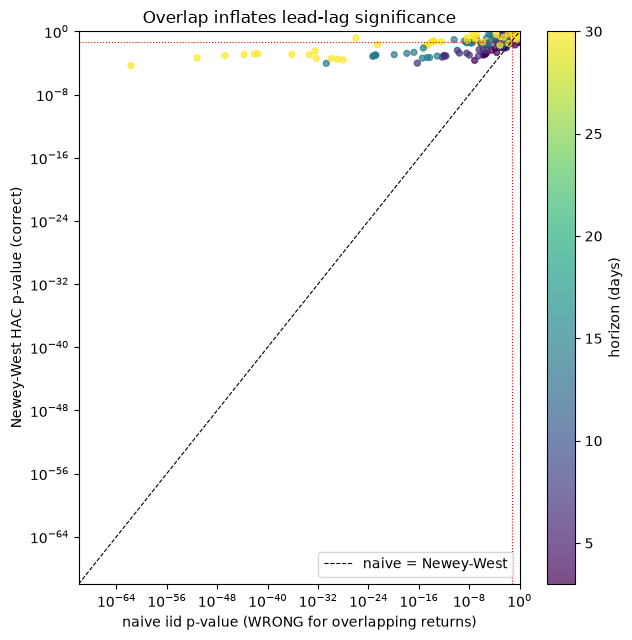

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
sc = ax.scatter(ll.naive_p.clip(1e-70), ll.nw_p.clip(1e-70), c=ll.horizon_days,
                cmap="viridis", s=18, alpha=0.7)
lims = [1e-70, 1]
ax.plot(lims, lims, "k--", lw=0.8, label="naive = Newey-West")
ax.axhline(0.05, color="red", lw=0.8, ls=":"); ax.axvline(0.05, color="red", lw=0.8, ls=":")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(*lims); ax.set_ylim(*lims)
ax.set_xlabel("naive iid p-value (WRONG for overlapping returns)")
ax.set_ylabel("Newey-West HAC p-value (correct)")
ax.set_title("Overlap inflates lead-lag significance")
plt.colorbar(sc, label="horizon (days)"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

## Lead-lag — what survives Newey-West, and how strong is it?

Effect size = |Spearman r|. Note how small it is even where significant, and which features dominate.

In [4]:
surv = ll[ll.nw_q < 0.05].copy()
surv["base"] = surv.feature.str.replace(r"_lag_\\d+d", "", regex=True)
print("Surviving lead-lag by base feature:")
print(surv.groupby(["asset","base"]).size().rename("n_survivors"))
print(f"\nmax |Spearman r| among survivors: {surv.spearman_r.abs().max():.3f}")
surv.sort_values("nw_q").head(10)[["asset","feature","horizon_days","spearman_r","naive_p","nw_p","nw_q"]]

Surviving lead-lag by base feature:
asset  base                
ADA    AdrActCnt               3
       AdrActCnt_lag_14d       4
       AdrActCnt_lag_1d        4
       AdrActCnt_lag_30d       3
       AdrActCnt_lag_3d        3
       AdrActCnt_lag_7d        3
       SplyCur                 3
BTC    IssTotUSD               4
       NVT_Tx_Basis            4
       NVT_Tx_Basis_lag_14d    4
       NVT_Tx_Basis_lag_1d     4
       NVT_Tx_Basis_lag_30d    4
       NVT_Tx_Basis_lag_3d     4
       NVT_Tx_Basis_lag_7d     4
Name: n_survivors, dtype: int64

max |Spearman r| among survivors: 0.341


,asset,feature,horizon_days,spearman_r,naive_p,nw_p,nw_q
74,BTC,NVT_Tx_Basis_lag_30d,7,-0.174095,5.646766e-17,0.000093,0.005333
117,BTC,NVT_Tx_Basis_lag_30d,14,-0.241119,1.999428e-31,0.000088,0.005333
160,BTC,NVT_Tx_Basis_lag_30d,30,-0.340605,2.041090e-62,0.000046,0.005333
31,BTC,NVT_Tx_Basis_lag_30d,3,-0.112498,7.022871e-08,0.000210,0.009016
58,BTC,NVT_Tx_Basis_lag_1d,7,-0.147465,1.070390e-12,0.000815,0.009798
62,BTC,NVT_Tx_Basis_lag_3d,7,-0.147214,1.196450e-12,0.000767,0.009798
23,BTC,NVT_Tx_Basis_lag_7d,3,-0.097375,2.791026e-06,0.001233,0.009798
19,BTC,NVT_Tx_Basis_lag_3d,3,-0.097207,2.846986e-06,0.001253,0.009798
66,BTC,NVT_Tx_Basis_lag_7d,7,-0.145940,1.957250e-12,0.000755,0.009798
70,BTC,NVT_Tx_Basis_lag_14d,7,-0.149984,5.059302e-13,0.000531,0.009798


## Granger — the cleanest test

Granger conditions on the return's **own past** and uses non-overlapping next-day returns, so it absorbs the autocorrelation/regime baseline that confounds lead-lag and MI.

In [5]:
print("Granger survivors (q<0.05):")
display(gr[gr.granger_q<0.05][["asset","feature","lag","granger_p","granger_q"]])
print("=> the only features that Granger-cause returns are PRICE features, no on-chain feature.")

Granger survivors (q<0.05):


,asset,feature,lag,granger_p,granger_q
142,BTC,Price_vs_MA7,7,4.530104e-09,7.610574e-07
143,BTC,Price_vs_MA7,14,4.117527e-08,3.458722e-06


=> the only features that Granger-cause returns are PRICE features, no on-chain feature.


## Mutual information — and why its hits are a trend confound

MI flags several features, but **the strongest are near-monotonic clocks**: `trend_vs_time` = |Spearman(feature, row-order)|. A feature with trend ≈ 1 is essentially a timestamp, so high MI with a regime-clustered return sign reflects *when* in the sample we are, not prediction. MI does not condition on the calendar; Granger and the ablation do, and they find no on-chain edge. Non-trending survivors are price-embedding valuation ratios (MVRV, NVT) or price volatility.

MI survivors (q<0.05): 14


,asset,feature,mi,mi_null_mean,trend_vs_time,mi_p,mi_q
43,ADA,SplyCur,0.371656,0.004193,1.000000,0.003322,0.014950
44,ADA,ActiveStakeADA,0.299658,0.004975,0.377634,0.003322,0.014950
45,ADA,StakingRatio,0.239348,0.003789,0.561767,0.003322,0.014950
0,BTC,HashRate_30d_MA,0.135996,0.004593,0.988390,0.003322,0.035714
1,BTC,CapMVRVCur,0.055402,0.004410,0.032778,0.003322,0.035714
46,ADA,Volatility_30d,0.050576,0.004436,0.304563,0.003322,0.014950
2,BTC,NVT_Tx_Basis,0.050414,0.004186,0.302515,0.003322,0.035714
47,ADA,NVT_Tx_Basis_lag_14d,0.040958,0.004616,0.135786,0.003322,0.014950
48,ADA,NVT_Tx_Basis_lag_30d,0.039850,0.003975,0.154719,0.003322,0.014950
49,ADA,NVT_Tx_Basis_lag_7d,0.039790,0.005004,0.127205,0.003322,0.014950


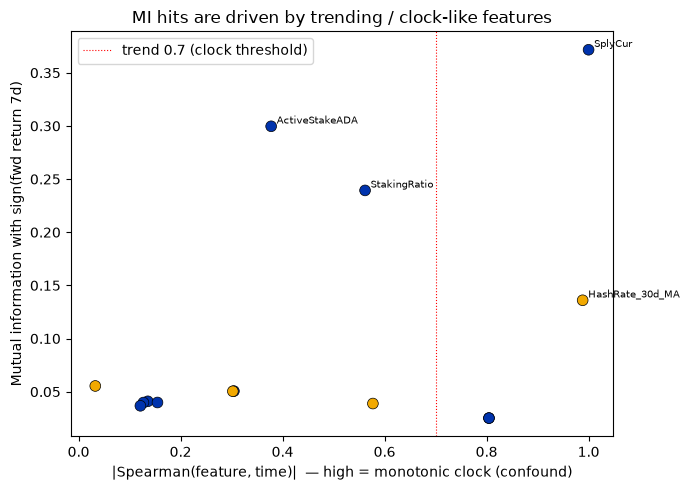

In [6]:
mi_s = mi[mi.mi_q<0.05].sort_values("mi", ascending=False)
print(f"MI survivors (q<0.05): {len(mi_s)}")
display(mi_s[["asset","feature","mi","mi_null_mean","trend_vs_time","mi_p","mi_q"]])

fig, ax = plt.subplots(figsize=(7,5))
c = np.where(mi_s.asset=="BTC", "#f2a900", "#0033ad")
ax.scatter(mi_s.trend_vs_time, mi_s.mi, c=c, s=60, edgecolor="k", lw=0.5)
for _, r in mi_s.iterrows():
    if r.mi > 0.08:
        ax.annotate(r.feature, (r.trend_vs_time, r.mi), fontsize=7,
                    xytext=(4,2), textcoords="offset points")
ax.axvline(0.7, color="red", ls=":", lw=0.8, label="trend 0.7 (clock threshold)")
ax.set_xlabel("|Spearman(feature, time)|  — high = monotonic clock (confound)")
ax.set_ylabel("Mutual information with sign(fwd return 7d)")
ax.set_title("MI hits are driven by trending / clock-like features")
ax.legend(); plt.tight_layout(); plt.show()

## Read

- **Overlap correction is the headline caveat.** The naive iid p-value flags dozens of "significant" lead-lag correlations; Newey-West removes ~60%. Any predictive-return study on overlapping horizons must correct for this or it will hallucinate signal.
- **What survives lead-lag is weak (|r| < ~0.18) and price-shaped** — valuation ratios that embed price (`NVT_Tx_Basis`, `IssTotUSD`) and supply/activity trend proxies (`SplyCur`, `AdrActCnt`).
- **MI flags more features, but its top hits are monotonic clocks** (`SplyCur`, `HashRate_30d_MA`, activity) — a trend/regime confound, not prediction. The non-trending survivors are price-derived (MVRV, NVT, volatility).
- **Granger — the one test that conditions on the return's own past — clears every on-chain feature**, leaving only price momentum (`Price_vs_MA7`).

**Converging conclusion:** across three independent model-free tests, once you correct for overlap (Newey-West), condition on the past (Granger), or notice the trend confound (MI), **no incremental on-chain directional signal remains** for BTC/ADA at daily frequency (2020–2026). Every surviving effect is price-driven (valuation mean-reversion, momentum) or a calendar artifact. This agrees with the ablation. See `SIGNAL_DETECTION_RESULTS.md`; next in `VALIDATION_PLAN.md` is the label redo (triple-barrier), and the Phase 3.3 staking leak audit before trusting any ADA feature.